In [5]:
# Importer les bibliothèques pour le traitement, le modèle SVM, l'évaluation et les visualisations
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Définir la fonction pour créer des caractéristiques pertinentes pour la classification des trajectoires
def feature_engineering(df):
    """Crée Growth Ratio, High Automation Risk, et Salary Experience Interaction."""
    df = df.copy()  # Copier le DataFrame pour éviter de modifier l'original
    # Calculer le ratio de croissance des ouvertures d'emploi (2030 vs 2024)
    df['Growth Ratio'] = (df['Projected Openings (2030)'] - df['Job Openings (2024)']) / df['Job Openings (2024)'].replace(0, 1)
    # Créer un indicateur binaire pour un risque d'automatisation > 70 %
    df['High Automation Risk'] = (df['Automation Risk (%)'] > 70).astype(int)
    # Calculer l'interaction entre salaire et expérience requise
    df['Salary Experience Interaction'] = df['Median Salary (USD)'] * df['Experience Required (Years)']
    return df

In [7]:
# Définir la fonction pour prétraiter les données (encodage et standardisation)
def preprocess_pipeline(df, features, target):
    """Vérifie les colonnes, encode les variables catégoriques, standardise les numériques."""
    # Vérifier que toutes les colonnes spécifiées existent pour éviter KeyError
    missing_cols = [col for col in features + [target] if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Colonnes manquantes : {missing_cols}")

    # Sélectionner les caractéristiques et la cible
    X = df[features].copy()
    y = df[target]

    # Identifier les colonnes catégoriques à encoder
    categorical_features = ['AI Impact Level', 'Required Education', 'Industry', 'Location']
    encoders = {}

    # Encoder les variables catégoriques
    for col in categorical_features:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        encoders[col] = le

    # Encoder la cible (Job Status)
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    encoders['target'] = le_target

    # Standardiser les caractéristiques numériques
    numerical_features = [col for col in features if col not in categorical_features]
    scaler = StandardScaler()
    X[numerical_features] = scaler.fit_transform(X[numerical_features])

    # Afficher les classes de la cible pour vérification
    print("Classes de la cible :", le_target.classes_)
    return X, y, encoders

In [8]:
# Charger le jeu de données ai_job.csv
df = pd.read_csv(r'C:\Users\meria\Downloads\mlProject\data\ai_job_trends_dataset.csv')

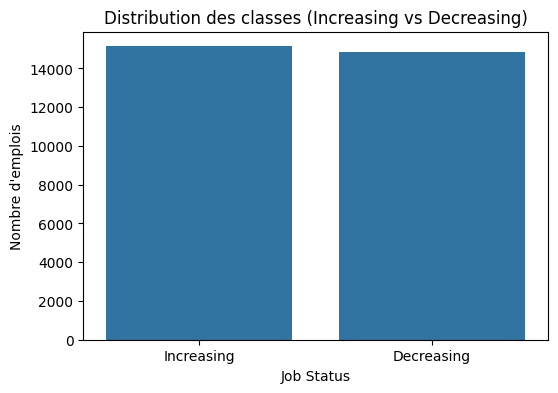

In [9]:
# Visualiser la distribution des classes de Job Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Job Status', data=df)
plt.title('Distribution des classes (Increasing vs Decreasing)')
plt.xlabel('Job Status')
plt.ylabel('Nombre d\'emplois')
plt.show()

In [10]:
# Appliquer l'ingénierie des caractéristiques pour ajouter Growth Ratio, High Automation Risk, etc.
df = feature_engineering(df)

In [11]:
# Définir les caractéristiques (y compris les nouvelles) et la cible
features = ['Median Salary (USD)', 'Experience Required (Years)', 'Job Openings (2024)',
            'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)',
            'Gender Diversity (%)', 'AI Impact Level', 'Required Education', 'Industry',
            'Location', 'Growth Ratio', 'High Automation Risk', 'Salary Experience Interaction']
target = 'Job Status'

In [12]:
# Prétraiter les données avec encodage et standardisation
X, y, encoders = preprocess_pipeline(df, features, target)

Classes de la cible : ['Decreasing' 'Increasing']


In [13]:
# Diviser les données en ensembles d'entraînement (80 %) et de test (20 %)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Afficher les dimensions des ensembles pour vérification
print("Dimensions entraînement :", X_train.shape, "Test :", X_test.shape)

Dimensions entraînement : (24000, 14) Test : (6000, 14)


In [14]:
# Entraîner un modèle SVM avec noyau RBF et poids équilibrés
svm_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42, probability=True)
svm_model.fit(X_train, y_train)
# Confirmer que l'entraînement est terminé
print("Modèle SVM entraîné.")

Modèle SVM entraîné.


Exactitude : 0.5


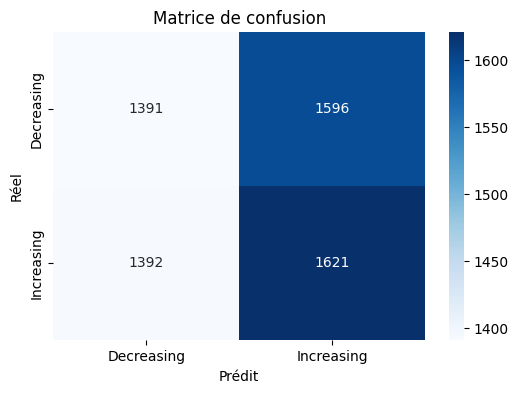

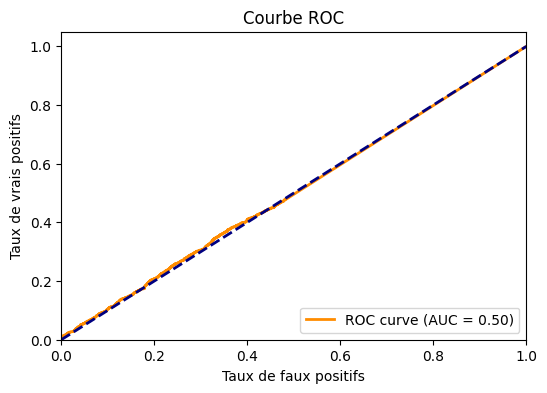

Rapport de classification :
              precision    recall  f1-score   support

  Decreasing       0.50      0.47      0.48      2987
  Increasing       0.50      0.54      0.52      3013

    accuracy                           0.50      6000
   macro avg       0.50      0.50      0.50      6000
weighted avg       0.50      0.50      0.50      6000



In [15]:
# Faire des prédictions sur l'ensemble de test
y_pred = svm_model.predict(X_test)
# Afficher l'exactitude du modèle
print("Exactitude :", round(accuracy_score(y_test, y_pred), 2))

# Générer et afficher la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoders['target'].classes_, yticklabels=encoders['target'].classes_)
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Générer et afficher la courbe ROC
y_prob = svm_model.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.show()

# Afficher le rapport de classification
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=encoders['target'].classes_))

In [ ]:
# Calculer l'importance des caractéristiques par permutation
perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10, random_state=42)
# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(np.array(features)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Importance (Permutation)')
plt.title('Importance des caractéristiques')
plt.show()

In [ ]:
# Afficher le nombre de vecteurs de support pour évaluer la complexité
print("Vecteurs de support :", len(svm_model.support_))

# Tester une prédiction sur un exemple
sample_job = X_test.iloc[0:1]
sample_pred = svm_model.predict(sample_job)
sample_pred_label = encoders['target'].inverse_transform نمونه_pred)[0]
# Afficher la prédiction pour l'exemple
print(f"Prédiction exemple : {sample_pred_label}")
sample_index = X_test.index[0]
# Afficher les détails de l'exemple pour contextualisation
print("Détails exemple :")
print(df.loc[sample_index, ['Job Title', 'Industry', 'Location', 'Automation Risk (%)', 'Growth Ratio']])

In [ ]:
# Afficher le nombre de vecteurs de support pour évaluer la complexité
print("Vecteurs de support :", len(svm_model.support_))

# Tester une prédiction sur un exemple
sample_job = X_test.iloc[0:1]
sample_pred = svm_model.predict(sample_job)
sample_pred_label = encoders['target'].inverse_transform نمونه_pred)[0]
# Afficher la prédiction pour l'exemple
print(f"Prédiction exemple : {sample_pred_label}")
sample_index = X_test.index[0]
# Afficher les détails de l'exemple pour contextualisation
print("Détails exemple :")
print(df.loc[sample_index, ['Job Title', 'Industry', 'Location', 'Automation Risk (%)', 'Growth Ratio']])

In [ ]:
# Définir une grille de paramètres pour optimiser le modèle SVM
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
# Effectuer une recherche par grille avec validation croisée
grid_search = GridSearchCV(SVC(class_weight='balanced', probability=True), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
# Afficher les meilleurs paramètres et l'exactitude
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure exactitude :", round(grid_search.best_score_, 2))
# Afficher l'exactitude sur l'ensemble de test
print("Exactitude test avec meilleur modèle :", round(accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)), 2))

In [ ]:
# Définir une grille de paramètres pour optimiser le modèle SVM
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
# Effectuer une recherche par grille avec validation croisée
grid_search = GridSearchCV(SVC(class_weight='balanced', probability=True), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
# Afficher les meilleurs paramètres et l'exactitude
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleure exactitude :", round(grid_search.best_score_, 2))
# Afficher l'exactitude sur l'ensemble de test
print("Exactitude test avec meilleur modèle :", round(accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)), 2))